In [1]:
import numpy as np
import matplotlib.pyplot as plt
from generators import MultipleSpeedCrossingBar
from networks import LateralInhibitoryLayer

# 1. Setup Generator (I.I.D. samples)
screen_size = 12
gen_params = MultipleSpeedCrossingBar.default_params()
gen_params['screen_size'] = screen_size
gen_params['bar_size'] = 1
gen_params['speed'] = 1
gen_params['noise'] = 0.05

gen = MultipleSpeedCrossingBar(gen_params)

# 2. Setup Network
hparams = LateralInhibitoryLayer.default_hparams((screen_size, screen_size, 1))
hparams['num_units_y'] = 36  # Creating 36 units to plot a 6x6 grid of Receptive Fields
hparams['w_lr'] = 0.01       # Feedforward learning rate
hparams['m_lr'] = 0.05       # Lateral inhibitory learning rate
hparams['w_update'] = 'bcm_abs' # Using a classic update rule for spatial RFs 

net = LateralInhibitoryLayer(hparams)


In [2]:

# 3. Training Loop
num_steps = 3000
errors = []

net.reset_network()

for step in range(num_steps):
    # Get an I.I.D. sample by re-randomizing positions each step
    gen.set_random_position()
    frame = gen.get_current_frame().copy()
    
    # Network forward and backward pass
    net.update_activations(frame, train=True)
    net.update_counts()
    
    # For i.i.d spatial samples, typically we update 'w' (feedforward) and 'm' (lateral)
    net.update_parameters(['w', 'm']) 
    
    # Measure reconstruction error
    recon = net.projection()
    mse = np.mean((frame.flatten() - recon.flatten())**2)
    errors.append(mse)
    
    # Reset network activations for the next independent sample
    net.new_epoch()

/Users/henriquereisaguiar/miniforge3/envs/networks/lib/python3.10/site-packages/scipy/stats/_entropy.py:133: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


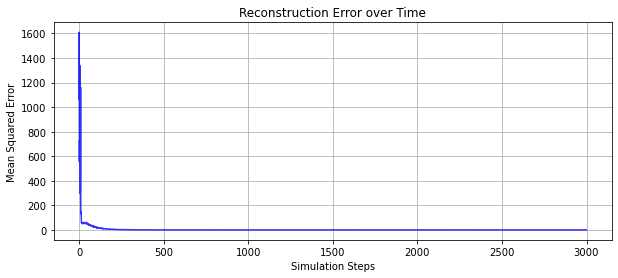

In [3]:
# 4. Plotting Reconstruction Error
plt.figure(figsize=(10, 4))
plt.plot(errors, alpha=0.8, color='blue')
plt.title("Reconstruction Error over Time")
plt.xlabel("Simulation Steps")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

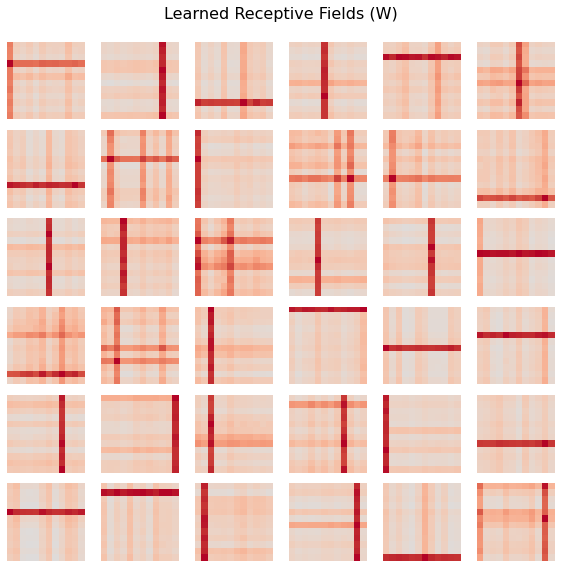

In [4]:
# 5. Plotting Learned Receptive Fields
W = net.w
num_units = W.shape[0]
grid_size = int(np.sqrt(num_units))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
fig.suptitle("Learned Receptive Fields (W)", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < num_units:
        # Reshape the flattened weights back to the 2D spatial arrangement
        rf = W[i].reshape(screen_size, screen_size)
        
        # Scale for visualization
        vmax = np.abs(rf).max()
        ax.imshow(rf, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()